In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",
header= 0,encoding= 'unicode_escape')

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Grandezza del database: ")
print(df.shape)

print("\nLa raccolta dei dati inizia da: ")
print(df["date"].min()) #inizio dei dati
print("a ")
print(df["date"].max()) #fine dei dati 
#5 rows x 29 columns

Grandezza del database: 
(19735, 29)

La raccolta dei dati inizia da: 
2016-01-11 17:00:00
a 
2016-05-27 18:00:00


In [2]:
#Creo delle variabili temporali 
df["hour"] = df["date"].dt.hour
df["minute"] = df["date"].dt.minute
df["dayofweek"] = df["date"].dt.dayofweek
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month


#l'ora è una variabile ciclica, possiamo utilizzare :
df["hour_sin"] = np.sin(
    2 * np.pi * (df["hour"] + df["minute"] / 60) / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * (df["hour"] + df["minute"] / 60) / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["dayofweek"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["dayofweek"] / 7
)

In [3]:
#Creo i lag del consumo 
#I dati sono presi ogni 10 minuti, quindi 1=10minuti
lags = [
    1, #10 minuti
    6, #60 minuti=1ora
    12, #2 ore
    36, #6 ore
    72, #12 ore
    144, #1 giorno 
    288, #2 giorni
    432, #3 giorni prima
    1008 #7 giorni prima
]

for lag in lags:
    df[f"Appliances_lag_{lag}"] = df["Appliances"].shift(lag)


In [4]:

#Aggiungiamo statistiche mobili: shift(t) calcola la media deelle informazioni disponibili prima del tempo t 
df["Appliances_roll_mean_1h"] = (
    df["Appliances"].shift(1).rolling(6).mean()
)

df["Appliances_roll_mean_3h"] = (
    df["Appliances"].shift(1).rolling(18).mean()
)

df["Appliances_roll_mean_6h"] = (
    df["Appliances"].shift(1).rolling(36).mean()
)

df["Appliances_roll_mean_24h"] = (
    df["Appliances"].shift(1).rolling(144).mean()
)


In [5]:
pip install pycatch22

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 58.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycatch22: filename=pycatch22-0.5.0-cp312-cp312-linux_x86_64.whl size=127425 sha256=da4f28de8b3b64a672d5c9ab5b87ec9f11de487cacc14d589289e05af3285186
  Stored in directory: /root/.cache/pip/wheels/de/53/fd/7249263f264f335813f991e188857091cba2e2c2454f545287
Successfully built pycatch22
Note: you may need to restart the kernel to use updated packages.


In [6]:
#La funzione ci permette di calcolare le caratteristiche catch22 su una sequenza temporale.
from pycatch22 import catch22_all

#Creo la funzione, uso 24 features, cioè includo anche la media e la deviazione standard
def extract_catch22_features(series):
    result = catch22_all(
        series.tolist(),
        catch24=True
    )

    return result["values"]


In [7]:
#Creo una finestra temporale
WINDOW = 144 #144 minuti = 24 ore

In [8]:
#applico catch22 solo su appliances 
def create_catch22_features(df, window=144):

    features = []
    
    values = df["Appliances"].values

    for i in range(window, len(df)):

        window_values = values[i-window:i]

        try:
            c22 = catch22_all(
                window_values.tolist(),
                catch24=True
            )

            features.append(c22["values"])

        except Exception:
            features.append([np.nan] * 24)

    feature_names = [
        f"catch22_{i}"
        for i in range(24)
    ]

    catch_df = pd.DataFrame(
        features,
        columns=feature_names
    )

    catch_df.index = df.index[window:]

    return catch_df

In [9]:

#risultato di catch22 applicato su Appliances
catch_features = create_catch22_features(df)

print('\nRisultato di catch22 applicato su Appliances\nStampo le 24 caratteristiche per ogni finestra temporale di un giorno:\n')
print(catch_features.head()) 
print('\n')
print(catch_features.shape)



Risultato di catch22 applicato su Appliances
Stampo le 24 caratteristiche per ogni finestra temporale di un giorno:

     catch22_0  catch22_1  catch22_2  catch22_3  catch22_4  catch22_5  \
144  -0.251747  -0.502624   1.786988          4   0.085878   0.123034   
145  -0.251747  -0.502624   1.787822          4   0.085878   0.123074   
146  -0.251747  -0.502624   1.788218          4   0.085878   0.123079   
147  -0.261109  -0.511416   1.772046          4   0.083348   0.139104   
148  -0.276117  -0.521555   1.724415          4   0.078449   0.154278   

     catch22_6  catch22_7  catch22_8  catch22_9  ...  catch22_14  catch22_15  \
144   0.692308        8.0   0.023401         13  ...    0.090278    0.542453   
145   0.699301        8.0   0.035102         14  ...    0.090278    0.543541   
146   0.692308        8.0   0.022313         14  ...    0.090278    0.543553   
147   0.699301        8.0   0.011701         14  ...    0.083333    0.536414   
148   0.699301        8.0   0.022585       

In [10]:
# ============================================================
# COLONNE DA ANALIZZARE CON CATCH22:  tengo in considerazione più  variabili 
# ============================================================

catch22_columns = [
    "Appliances",
    "lights",
    "T_out",
    "RH_out",
    "Windspeed"
]

# Controllo
print('dataset su cui applicare catch22:\n')
print(df[catch22_columns].head())


dataset su cui applicare catch22:

   Appliances  lights     T_out  RH_out  Windspeed
0          60      30  6.600000    92.0   7.000000
1          60      30  6.483333    92.0   6.666667
2          50      30  6.366667    92.0   6.333333
3          50      40  6.250000    92.0   6.000000
4          60      40  6.133333    92.0   5.666667


In [11]:

# ============================================================
# ESTRAZIONE CATCH24
# ============================================================

catch22_features = []

for i in range(WINDOW, len(df)):

    row_features = {}

    for column in catch22_columns:

        # Ultime 24 ore disponibili prima dell'istante i
        window = df[column].iloc[i-WINDOW:i].values

        # Calcolo delle 24 feature (catch22 + 2 statistiche)
        result = catch22_all(
            window.tolist(),
            catch24=True
        )

        # Salva ogni feature con il nome della variabile originale
        for name, value in zip(
            result["names"],
            result["values"]
        ):
            row_features[f"{column}_{name}"] = value

    catch22_features.append(row_features)


# ============================================================
#  CREAZIONE DATAFRAME DELLE FEATURE
# ============================================================

catch22_df = pd.DataFrame(catch22_features)


In [12]:

print("\nDimensioni catch22:")
print(catch22_df.shape)


Dimensioni catch22:
(19591, 120)


In [13]:
print("\nPrime colonne:")
print(catch22_df.columns[:10])


Prime colonne:
Index(['Appliances_DN_HistogramMode_5', 'Appliances_DN_HistogramMode_10',
       'Appliances_CO_f1ecac', 'Appliances_CO_FirstMin_ac',
       'Appliances_CO_HistogramAMI_even_2_5', 'Appliances_CO_trev_1_num',
       'Appliances_MD_hrv_classic_pnn40',
       'Appliances_SB_BinaryStats_mean_longstretch1',
       'Appliances_SB_TransitionMatrix_3ac_sumdiagcov',
       'Appliances_PD_PeriodicityWang_th0_01'],
      dtype='object')


In [14]:
print("\nPrime righe:")
print(catch22_df.head())


Prime righe:
   Appliances_DN_HistogramMode_5  Appliances_DN_HistogramMode_10  \
0                      -0.251747                       -0.502624   
1                      -0.251747                       -0.502624   
2                      -0.251747                       -0.502624   
3                      -0.261109                       -0.511416   
4                      -0.276117                       -0.521555   

   Appliances_CO_f1ecac  Appliances_CO_FirstMin_ac  \
0              1.786988                          4   
1              1.787822                          4   
2              1.788218                          4   
3              1.772046                          4   
4              1.724415                          4   

   Appliances_CO_HistogramAMI_even_2_5  Appliances_CO_trev_1_num  \
0                             0.085878                  0.123034   
1                             0.085878                  0.123074   
2                             0.085878          

In [15]:

# ============================================================
# ALLINEAMENTO CON IL DATASET ORIGINALE
# ============================================================

df_model = df.iloc[WINDOW:].copy().reset_index(drop=True)

catch22_df = catch22_df.reset_index(drop=True)


In [16]:
# ============================================================
# UNIONE DATASET + FEATURE CATCH22
# ============================================================

df_model = pd.concat(
    [
        df_model,
        catch22_df
    ],
    axis=1
)

In [17]:
# ============================================================
# CONTROLLO FINALE
# ============================================================

print("\nDimensioni dataset finale (UNIONE DATASET + FEATURE CATCH22):")
print(df_model.shape)

print("\nDataset finale:")
print(df_model.head())



Dimensioni dataset finale (UNIONE DATASET + FEATURE CATCH22):
(19591, 171)

Dataset finale:
                 date  Appliances  lights         T1       RH_1         T2  \
0 2016-01-12 17:00:00          60       0  20.066667  42.833333  19.000000   
1 2016-01-12 17:10:00          60      10  20.000000  42.672500  19.000000   
2 2016-01-12 17:20:00         210      20  20.000000  42.530000  18.990000   
3 2016-01-12 17:30:00         380      20  20.033333  43.496667  18.902222   
4 2016-01-12 17:40:00         370      40  20.033333  42.963333  18.890000   

        RH_2         T3       RH_3     T4  ...  \
0  42.418182  19.790000  44.700000  19.26  ...   
1  42.433333  19.790000  44.663333  19.20  ...   
2  42.471818  19.790000  44.590000  19.20  ...   
3  42.580000  19.823333  44.590000  19.20  ...   
4  42.560000  19.890000  44.590000  19.36  ...   

   Windspeed_DN_OutlierInclude_n_001_mdrmd  \
0                                 0.097222   
1                                 0.083333   

In [18]:

# ============================================================
# CONTROLLO FEATURE CATCH22
# ============================================================
print('\n---Controllo feature catch22---')
catch22_feature_names = [
    column
    for column in df_model.columns
    if any(
        column.startswith(variable + "_")
        for variable in catch22_columns
    )
]

print("\nNumero feature catch22:")
print(len(catch22_feature_names))


---Controllo feature catch22---

Numero feature catch22:
133


In [19]:
print("\nFeature catch22:")
for feature in catch22_feature_names:
    print(feature)


Feature catch22:
Appliances_lag_1
Appliances_lag_6
Appliances_lag_12
Appliances_lag_36
Appliances_lag_72
Appliances_lag_144
Appliances_lag_288
Appliances_lag_432
Appliances_lag_1008
Appliances_roll_mean_1h
Appliances_roll_mean_3h
Appliances_roll_mean_6h
Appliances_roll_mean_24h
Appliances_DN_HistogramMode_5
Appliances_DN_HistogramMode_10
Appliances_CO_f1ecac
Appliances_CO_FirstMin_ac
Appliances_CO_HistogramAMI_even_2_5
Appliances_CO_trev_1_num
Appliances_MD_hrv_classic_pnn40
Appliances_SB_BinaryStats_mean_longstretch1
Appliances_SB_TransitionMatrix_3ac_sumdiagcov
Appliances_PD_PeriodicityWang_th0_01
Appliances_CO_Embed2_Dist_tau_d_expfit_meandiff
Appliances_IN_AutoMutualInfoStats_40_gaussian_fmmi
Appliances_FC_LocalSimple_mean1_tauresrat
Appliances_DN_OutlierInclude_p_001_mdrmd
Appliances_DN_OutlierInclude_n_001_mdrmd
Appliances_SP_Summaries_welch_rect_area_5_1
Appliances_SB_BinaryStats_diff_longstretch0
Appliances_SB_MotifThree_quantile_hh
Appliances_SC_FluctAnal_2_rsrangefit_50_1_lo

In [20]:

#Creazione del target futuro 
#tempo t        → informazioni che il modello vede
#tempo t + 10m  → target da prevedere
df_model["target"] = df_model["Appliances"].shift(-144)

# L'ultima riga non ha un valore futuro da prevedere
df_model = df_model.dropna(subset=["target"]).reset_index(drop=True)

print(df_model[["date", "Appliances", "target"]].head())

# informazioni fino alle 17:00 → prevedi 17:10
# Alle 17:10 Appliances è 60, e alle 17:20 è 210,
# quindi il target da predirre per le 17.10 è 210 


                 date  Appliances  target
0 2016-01-12 17:00:00          60    90.0
1 2016-01-12 17:10:00          60   100.0
2 2016-01-12 17:20:00         210    90.0
3 2016-01-12 17:30:00         380   110.0
4 2016-01-12 17:40:00         370    90.0


In [21]:
# ============================================================
# ROLLING STATISTICS
# ============================================================
#Aggiungiamo informazioni sull'andamento recente del consumo.

df_model["Appliances_roll_mean_1h"] = (  #calcolo la media del consumo dell'ultima ora, usando solo
    df_model["Appliances"]               # i dati disponibili prima dell'istante corrente.
    .shift(1)
    .rolling(6)
    .mean()
)

df_model["Appliances_roll_std_1h"] = ( #deviazione standard dell'ultima ora 
    df_model["Appliances"]
    .shift(1)
    .rolling(6)
    .std()
)

df_model["Appliances_roll_mean_3h"] = ( #media ultime 3 ore ..etc
    df_model["Appliances"]
    .shift(1)
    .rolling(18)
    .mean()
)

df_model["Appliances_roll_std_3h"] = (
    df_model["Appliances"]
    .shift(1)
    .rolling(18)
    .std()
)

df_model["Appliances_roll_mean_6h"] = (
    df_model["Appliances"]
    .shift(1)
    .rolling(36)
    .mean()
)

df_model["Appliances_roll_mean_24h"] = (
    df_model["Appliances"]
    .shift(1)
    .rolling(144)
    .mean()
)

In [22]:
# ============================================================
# FEATURE TEMPORALI CICLICHE
# ============================================================

time_in_hours = (
    df_model["hour"]
    + df_model["minute"] / 60
)

df_model["hour_sin"] = np.sin(
    2 * np.pi * time_in_hours / 24
)

df_model["hour_cos"] = np.cos(
    2 * np.pi * time_in_hours / 24
)

df_model["dow_sin"] = np.sin(
    2 * np.pi * df_model["dayofweek"] / 7
)

df_model["dow_cos"] = np.cos(
    2 * np.pi * df_model["dayofweek"] / 7
)

In [23]:
# ============================================================
# RIMOZIONE NaN
# ============================================================

df_model = df_model.dropna().reset_index(drop=True)

print("Dimensioni dataset:")
print(df_model.shape)

Dimensioni dataset:
(18174, 174)


In [24]:
# ============================================================
# DEFINISCO X E Y PER 
# ============================================================

Y = df_model["target"] #y è il df target definito sopra dalllo shift

columns_to_drop = [
    "date",
    "target"
]

X = df_model.drop(     #X è il nostro db di partenza 
    columns=columns_to_drop
)

print("X:", X.shape)
print("y:", Y.shape)

X: (18174, 172)
y: (18174,)


In [25]:
# ============================================================
# TRAIN / VALIDATION / TEST
# ============================================================

#0%             70%        85%             100%
#|---------------|----------|----------------|
#     TRAIN       VALIDATION      TEST
#      700          150           150

n = len(df_model)

train_end = int(n * 0.70) #70% training
val_end = int(n * 0.85) #15% validation

X_train = X.iloc[:train_end]
Y_train = Y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
Y_val = Y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
Y_test = Y.iloc[val_end:]

print("TRAIN:", X_train.shape)
print("VALIDATION:", X_val.shape)
print("TEST:", X_test.shape) #15% testing

TRAIN: (12721, 172)
VALIDATION: (2726, 172)
TEST: (2727, 172)


In [26]:
# ============================================================
# 24. MODELLO PER FEATURE SELECTION
# ============================================================

from xgboost import XGBRegressor
from sklearn.feature_selection import SelectFromModel

selector_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

selector_model.fit(
    X_train,
    Y_train
)

print('')

In [27]:
# ============================================================
# 25. FEATURE IMPORTANCE
# ============================================================

importances = pd.Series(
    selector_model.feature_importances_,
    index=X_train.columns
)

importances = importances.sort_values(
    ascending=False
)

print("\nFeature più importanti:")
print(importances.head(30))


Feature più importanti:
hour                                                  0.114424
dayofweek                                             0.031921
hour_cos                                              0.017247
T_out_SB_BinaryStats_diff_longstretch0                0.016075
T8                                                    0.014055
T_out_DN_Mean                                         0.013526
T_out_SP_Summaries_welch_rect_centroid                0.012915
hour_sin                                              0.012888
Appliances_DN_Spread_Std                              0.011625
Windspeed_SB_BinaryStats_diff_longstretch0            0.011239
lights_CO_f1ecac                                      0.010507
lights_FC_LocalSimple_mean1_tauresrat                 0.009749
Appliances_MD_hrv_classic_pnn40                       0.009471
Appliances_CO_FirstMin_ac                             0.009351
Appliances_roll_mean_24h                              0.009247
Appliances                    

In [28]:
print('rv1 e rv2 sono solo rumore per testare che il modello sappia riconoscere le feautures più e meno importanti.\nCome possiamo osservare il modello ha capito che hanno una importanza molto bassa. ')

print("\nImportanza rv1:")
print(importances.get("rv1", 0))

print("\nImportanza rv2:")
print(importances.get("rv2", 0))

rv1 e rv2 sono solo rumore per testare che il modello sappia riconoscere le feautures più e meno importanti.
Come possiamo osservare il modello ha capito che hanno una importanza molto bassa. 

Importanza rv1:
0.002019237

Importanza rv2:
0.0025081807


Visualizziamo con un istogramma a barre le 25 features più importanti.


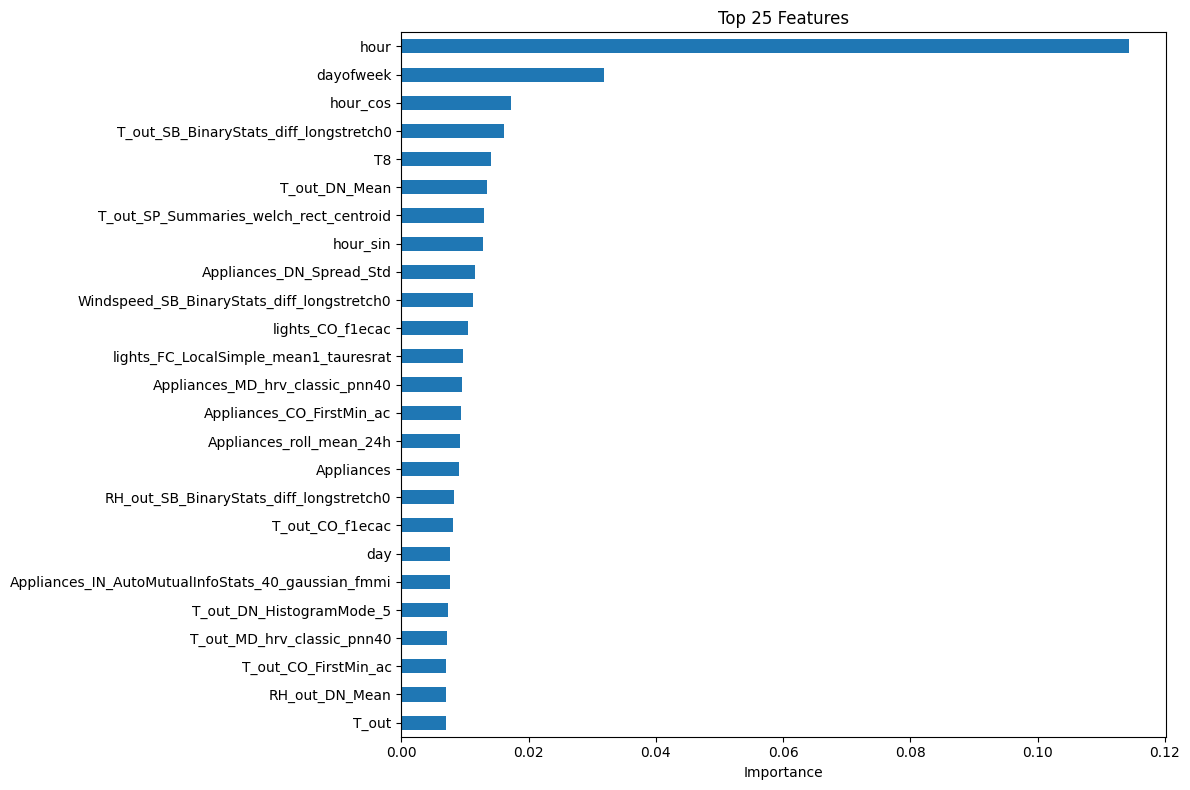

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

importances.head(25).sort_values().plot(
    kind="barh"
)

print('Visualizziamo con un istogramma a barre le 25 features più importanti.')

plt.title("Top 25 Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Possiamo osservare che Appliances ha ua correlazione molto alta con il giorno della settimana (dow = Day Of Week), e con Appliances con lag applicato (i consumi tra 10 minuti).

In [30]:
#Come threshold deciso di utilizzare la media tra le 25 feature

threshold="median"

In [31]:
# ============================================================
# 27. FEATURE SELECTION
# ============================================================
selector = SelectFromModel(
    selector_model,
    threshold="median",
    prefit=True
)

X_train_selected = selector.transform(X_train.values)
X_val_selected = selector.transform(X_val.values)
X_test_selected = selector.transform(X_test.values)

print("Feature originali:", X_train.shape[1])
print("Feature selezionate:", X_train_selected.shape[1])

Feature originali: 172
Feature selezionate: 86


In [32]:
# ============================================================
# FEATURE SELEZIONATE
# ============================================================

selected_features = X_train.columns[
    selector.get_support()
]

print("\nFeature selezionate:")

for feature in selected_features:
    print(feature)


Feature selezionate:
Appliances
T2
T3
RH_6
T8
T9
T_out
Press_mm_hg
RH_out
hour
dayofweek
day
hour_sin
hour_cos
dow_cos
Appliances_roll_mean_1h
Appliances_roll_mean_6h
Appliances_roll_mean_24h
Appliances_CO_f1ecac
Appliances_CO_FirstMin_ac
Appliances_MD_hrv_classic_pnn40
Appliances_SB_BinaryStats_mean_longstretch1
Appliances_IN_AutoMutualInfoStats_40_gaussian_fmmi
Appliances_FC_LocalSimple_mean1_tauresrat
Appliances_DN_OutlierInclude_p_001_mdrmd
Appliances_SB_MotifThree_quantile_hh
Appliances_SP_Summaries_welch_rect_centroid
Appliances_FC_LocalSimple_mean3_stderr
Appliances_DN_Spread_Std
lights_DN_HistogramMode_5
lights_DN_HistogramMode_10
lights_CO_f1ecac
lights_CO_FirstMin_ac
lights_CO_HistogramAMI_even_2_5
lights_CO_trev_1_num
lights_MD_hrv_classic_pnn40
lights_IN_AutoMutualInfoStats_40_gaussian_fmmi
lights_FC_LocalSimple_mean1_tauresrat
lights_DN_OutlierInclude_p_001_mdrmd
lights_DN_OutlierInclude_n_001_mdrmd
lights_SP_Summaries_welch_rect_area_5_1
lights_DN_Mean
T_out_DN_Histogram

Possiamo osservare come tra le feauture selezionate ci sia Appliances ovviamente, l'umodità, la temperatura interna e esterna, l'ora, il giorno e il mese. 

In [33]:
print("\nrv1 selezionata:")
print("rv1" in selected_features)

print("\nrv2 selezionata:")
print("rv2" in selected_features)

print('Possiamo osservare che rv non è tra la feature selezionate, il modello la lascia fuori correttamente.')


rv1 selezionata:
False

rv2 selezionata:
False
Possiamo osservare che rv non è tra la feature selezionate, il modello la lascia fuori correttamente.


In [34]:
# ============================================================
# MODELLO FINALE CON FEATURE SELEZIONATE
# ============================================================

model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_selected,
    Y_train,
    eval_set=[
        (X_val_selected, Y_val)
    ],
    verbose=False
)

print ('')

In [35]:
# ============================================================
# PREDIZIONE
# ============================================================

pred = model.predict(
    X_test_selected
)

In [36]:
# ============================================================
# METRICHE
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    Y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        Y_test,
        pred
    )
)

r2 = r2_score(
    Y_test,
    pred
)

print("\n==============================")
print("RISULTATI XGBOOST + CATCH24")
print("==============================")

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


RISULTATI XGBOOST + CATCH24
MAE  : 89.5257
RMSE : 113.9501
R²   : -0.5391


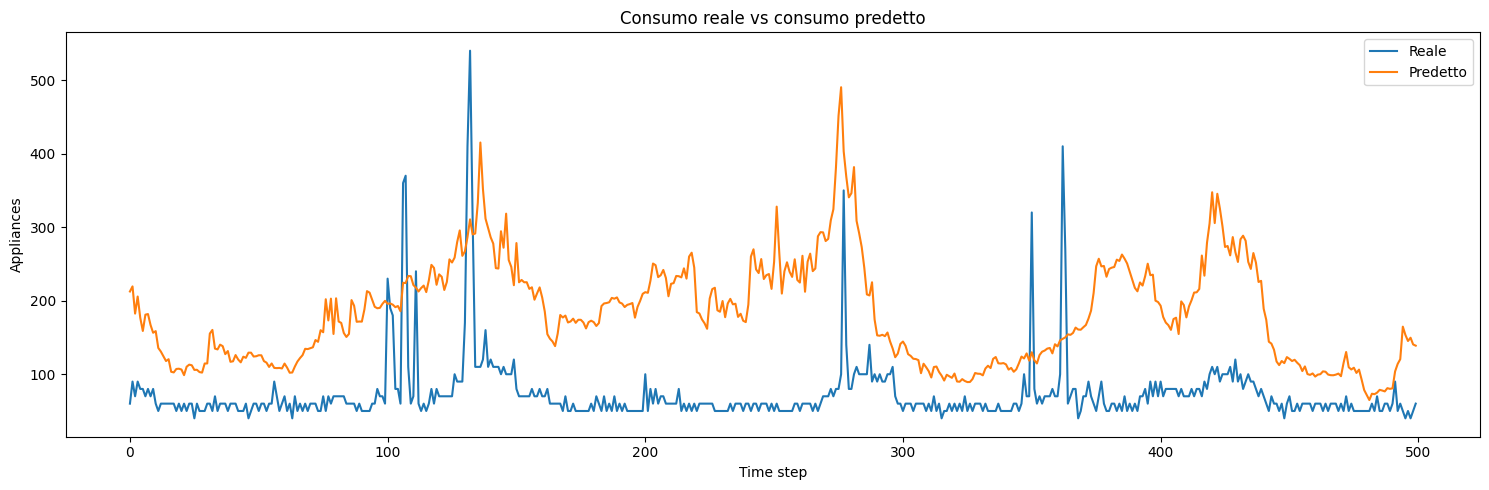

In [37]:
# ============================================================
# 32. REALE VS PREDETTO
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    Y_test.values[:500],
    label="Reale"
)

plt.plot(
    pred[:500],
    label="Predetto"
)

plt.xlabel("Time step")
plt.ylabel("Appliances")
plt.title("Consumo reale vs consumo predetto")

plt.legend()
plt.tight_layout()
plt.show()

Il modello tende a predirre molto di più rispetto al consumo effettivo, ma sembra riconoscere i picchi. 
Vediamo dove il modello sbaglia.

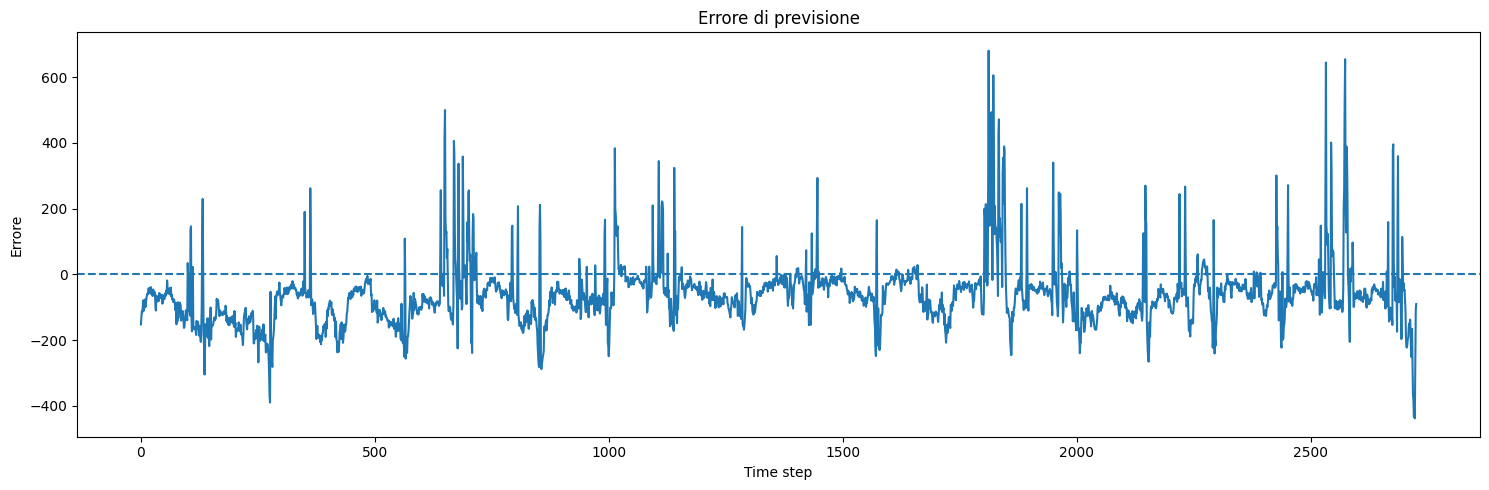

In [38]:
# ============================================================
# ERRORE
# ============================================================

errors = Y_test.values - pred

plt.figure(figsize=(15, 5))

plt.plot(errors)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time step")
plt.ylabel("Errore")
plt.title("Errore di previsione")

plt.tight_layout()
plt.show()

# CONCLUSIONE:

**catch22** non è lo strumento giusto qui.
catch22 è pensato per riassumere intere serie storiche (per classificazione/clustering di serie), non per essere ricalcolato riga per riga su una finestra scorrevole come feature di regressione one-step-ahead. È anche molto costoso da calcolare e in questo contesto aggiunge soprattutto rumore correlato, non segnale nuovo rispetto a lag/rolling semplici.
Catch22 (24 feature) su 5 variabili diverse → 120 feature, più una ventina di feature "normali" (lag, rolling, cicliche). Totale ~140 feature per un dataset di circa 14-15 mila righe. È un rapporto feature/righe sbilanciato.
